## 10 Translating to Business Decisions

How to translate physical parameters (E0, E_eq, γ, τ) into concrete actions for the retention and customer success team.

-> This physical model answers those questions with interpretable parameters:
- E_eq: Is the customer structurally loyal or structurally fragile?
- γ / τ: How long does it take to recover from a negative event?
- E0: What is their current state?
- F(t): What perturbations have they experienced?


### Setup


In [1]:
import os
import sqlite3
import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, ROOT)
os.chdir(os.path.join(ROOT, 'notebooks'))

from src.business import (  
    apply_segmentation,
    compute_economic_impact,
    impact_table,
    optimize_threshold,)
from src.physics import E_CRITICAL, E0_AT_RISK_THRESHOLD 
from src.visualization import PALETTE, set_style  

set_style()

try:
    LIFELINES_OK = True
except Exception:
    LIFELINES_OK = False

DATA_DIR = os.path.join(ROOT, 'data')
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()
df_model = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'], drop_first=True)

conn = sqlite3.connect(':memory:')
df.to_sql('telco', conn, if_exists='replace', index=False)
df_clean.to_sql('telco_clean', conn, if_exists='replace', index=False)

print(f'Ready: {len(df):,} customers | churn rate {df.Churn_bin.mean():.1%}')


Ready: 7,043 customers | churn rate 26.5%


### Strategic segmentation by physical parameters

In [2]:
df_final = apply_segmentation(df_final)

print('Segment distribution:')
print()
dist = df_final.groupby('segment').agg(n=('segment','count'), actual_churn_rate=('Churn_bin','mean'),
    prob_mean=('prob_churn_calibrated','mean'), tau_median=('tau','median'),
    E_eq_mean=('E_eq','mean'),).round(3).sort_values('actual_churn_rate', ascending=False)
print(dist.to_string())

Segment distribution:

                                  n  actual_churn_rate  prob_mean  tau_median  E_eq_mean
segment                                                                                 
High Risk / Fragile            1788              0.607      0.614       6.859      0.415
High Risk / Medium resilience   179              0.547      0.510       5.382      0.594
Uncertain                       371              0.291      0.271       4.068      0.771
Medium Risk / Fragile          1129              0.276      0.288       5.382      0.616
Stable                         3576              0.074      0.071       3.499      0.930


## How to use this model: practical guide

Segmentation matrix γ × risk:

|  | γ HIGH (τ < 5m), responds quickly | γ LOW (τ > 15m), responds slowly |
|---|---|---|
| HIGH RISK (prob > 0.65) | Immediate discount, reacts within days, ROI high and fast | Personalized plan, human contact needed, ROI high but slow |
| MEDIUM RISK (0.35–0.65) | Upsell / upgrade, optimal timing window | Monitoring + alert, do not spend yet |
| LOW RISK (prob < 0.35) | No intervention, loyal customer | No intervention — structurally loyal |

Additional signal: E_eq
- E_eq > 0.25: structurally loyal -> naturally returns to equilibrium
- E_eq < 0.25: intrinsic risk -> will churn even without negative events

Customers with intrinsic risk need an offer redesign, not just a campaign.

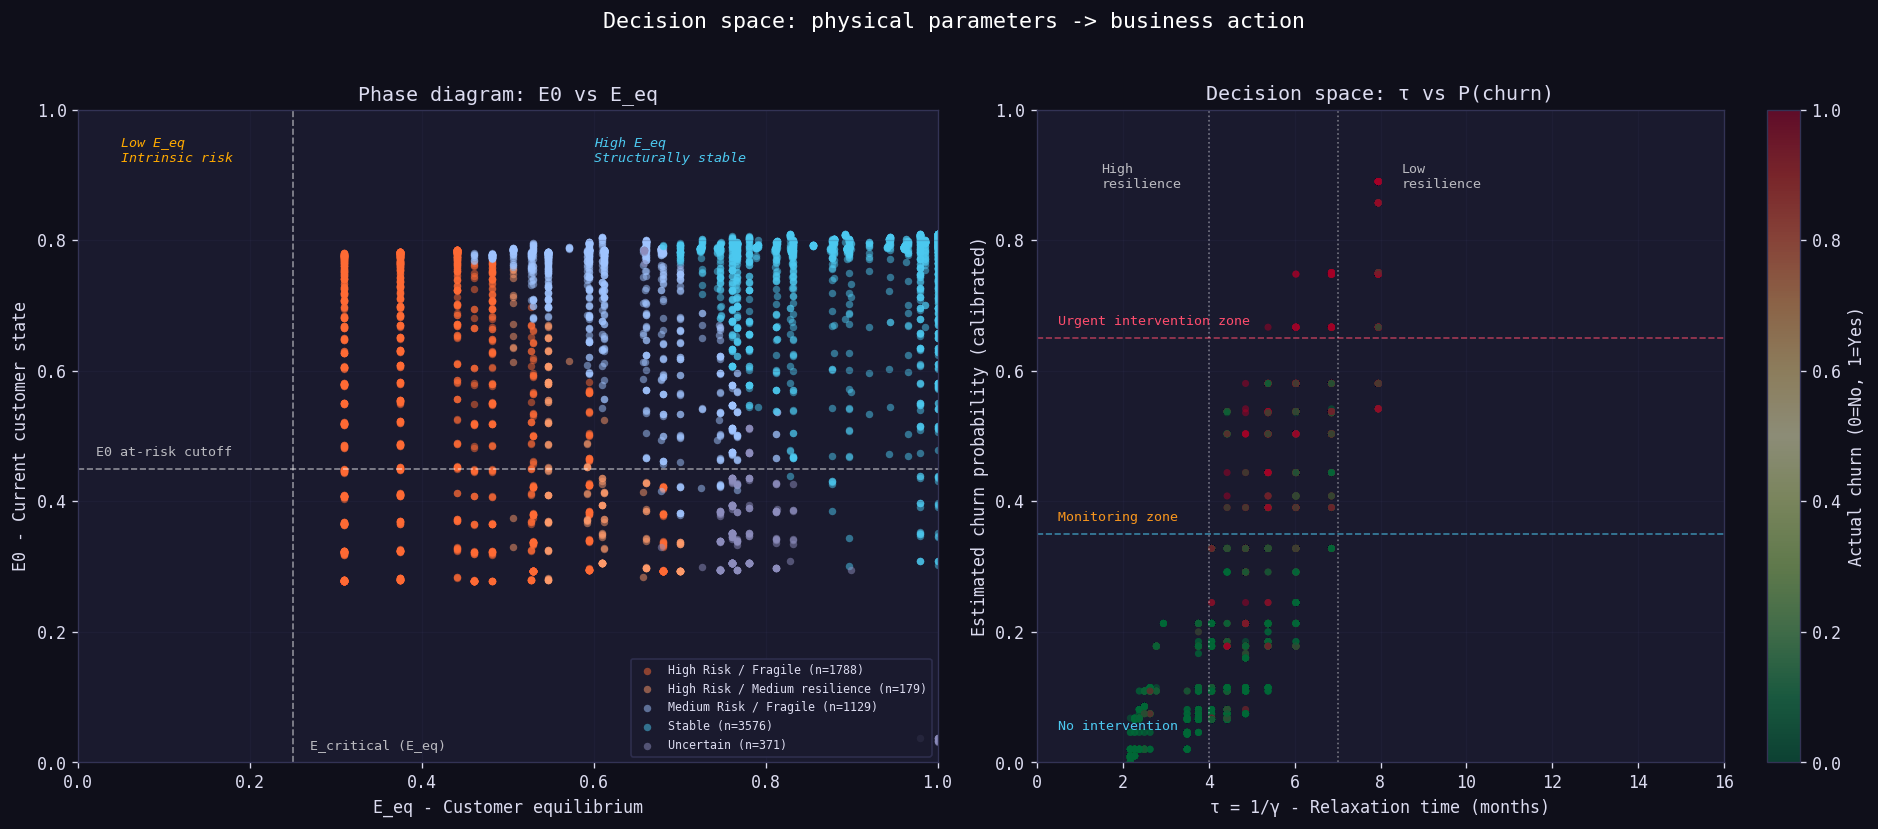

In [3]:
# Phase diagram E0 vs E_eq colored by recommended action
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Decision space: physical parameters -> business action', fontsize=13, color='white')

# Axis 1: phase diagram E0 vs E_eq
ax = axes[0]
segment_colors = {
    'High Risk / Resilient': PALETTE['churn'],
    'High Risk / Fragile': '#FF6B35',
    'High Risk / Medium resilience': '#FF9B6B',
    'Structural Risk': '#FFAA00',
    'Medium Risk / Resilient': PALETTE['accent'],
    'Medium Risk / Fragile': '#A0C4FF',
    'Stable': PALETTE['no_churn'],
    'Uncertain': PALETTE['neutral'],}

for seg, color in segment_colors.items():
    mask = df_final['segment'] == seg
    if mask.sum() > 0:
        ax.scatter(df.loc[mask, 'E_eq'], df.loc[mask, 'E0'], c=color, alpha=0.5, s=20, label=f'{seg} (n={mask.sum()})', linewidths=0)

ax.axvline(E_CRITICAL, color='white', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(E0_AT_RISK_THRESHOLD, color='white', linestyle='--', alpha=0.5, linewidth=1)
ax.text(0.02, E0_AT_RISK_THRESHOLD + 0.02, 'E0 at-risk cutoff', color='white', fontsize=8, alpha=0.7)
ax.text(E_CRITICAL + 0.02, 0.02, 'E_critical (E_eq)', color='white', fontsize=8, alpha=0.7)

# Quadrant annotations
ax.text(0.05, 0.92, 'Low E_eq\nIntrinsic risk', color='#FFAA00', fontsize=8, ha='left', style='italic')
ax.text(0.60, 0.92, 'High E_eq\nStructurally stable', color=PALETTE['no_churn'], fontsize=8, ha='left', style='italic')

ax.set_xlabel('E_eq - Customer equilibrium')
ax.set_ylabel('E0 - Current customer state')
ax.set_title('Phase diagram: E0 vs E_eq')
ax.legend(fontsize=7, loc='lower right', ncol=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)

# Axis 2: τ vs churn probability
ax2 = axes[1]
scatter = ax2.scatter(df['tau'], df_final['prob_churn_calibrated'], c=df['Churn_bin'], cmap='RdYlGn_r', alpha=0.5, s=18, linewidths=0)
ax2.axhline(0.65, color=PALETTE['churn'], linestyle='--', alpha=0.6, linewidth=1)
ax2.axhline(0.35, color=PALETTE['no_churn'], linestyle='--', alpha=0.6, linewidth=1)
ax2.axvline(4, color='white', linestyle=':', alpha=0.4, linewidth=1)
ax2.axvline(7, color='white', linestyle=':', alpha=0.4, linewidth=1)

ax2.text(0.5, 0.67, 'Urgent intervention zone', color=PALETTE['churn'], fontsize=8)
ax2.text(0.5, 0.37, 'Monitoring zone', color=PALETTE['accent'], fontsize=8)
ax2.text(0.5, 0.05, 'No intervention', color=PALETTE['no_churn'], fontsize=8)
ax2.text(1.5, 0.88, 'High\nresilience', color='white', fontsize=8, alpha=0.7)
ax2.text(8.5, 0.88, 'Low\nresilience', color='white', fontsize=8, alpha=0.7)

ax2.set_xlabel('τ = 1/γ - Relaxation time (months)')
ax2.set_ylabel('Estimated churn probability (calibrated)')
ax2.set_title('Decision space: τ vs P(churn)')
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 16)
plt.colorbar(scatter, ax=ax2, label='Actual churn (0=No, 1=Yes)')
ax2.grid(alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(ROOT, 'plots', '10_decision_space.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### Concrete examples: customer profiles

In [4]:
df = df_final.copy()
# Show 5 real customers with their physical profile and recommended action
profile_cols = ['tenure', 'Contract', 'MonthlyCharges', 'E0', 'E_eq',
               'gamma', 'tau', 'resilience', 'prob_churn_calibrated', 'sigma_prob', 'segment', 'action', 'Churn_bin']

# One customer per main segment
example_segments = ['High Risk / Resilient', 'High Risk / Fragile', 'Medium Risk / Resilient', 'Structural Risk', 'Stable',]

profiles_list = []
for seg in example_segments:
    subset = df[df_final['segment'] == seg]
    if len(subset) > 0:
        profiles_list.append(subset.iloc[0])

profile_df = pd.DataFrame(profiles_list)[[c for c in profile_cols if c in df.columns]]

for _, row in profile_df.iterrows():
    print()
    print(f"Segment : {row.get('segment','?')}")
    print(f"Contract : {row.get('Contract','?')} | Tenure: {row.get('tenure','?'):.0f}m | $:{row.get('MonthlyCharges','?'):.0f}/m")
    print(f"E0={row.get('E0',0):.3f}  E_eq={row.get('E_eq',0):.3f}  γ={row.get('gamma',0):.3f}  τ={row.get('tau',0):.1f}m  [{row.get('resilience','?')}]")
    print(f"P(churn) : {row.get('prob_churn_calibrated',0):.1%} ± {row.get('sigma_prob',0):.1%}")
    print(f"Action : {row.get('action','?')}")
    print(f"Actual churn: {'YES' if row.get('Churn_bin',0)==1 else 'NO'}")
print()


Segment : High Risk / Fragile
Contract : Month-to-month | Tenure: 1m | $:30/m
E0=0.295  E_eq=0.595  γ=0.166  τ=6.0m  [Low]
P(churn) : 58.1% ± 2.4%
Action : Personalized plan + human contact, slow response to incentives
Actual churn: NO

Segment : Stable
Contract : One year | Tenure: 34m | $:57/m
E0=0.796  E_eq=1.000  γ=0.226  τ=4.4m  [Medium]
P(churn) : 6.8% ± 2.3%
Action : Do not invest in retention, loyal customer
Actual churn: NO



###  Economic impact of the model

 **Note on model used here:** `prob_churn` is computed by the physics-based formula
 `P(churn) = 1 - E(t=6m)`, not by the sklearn classifiers evaluated in notebook 09.
 The raw version of this formula was systematically overconfident (mean ≈ 50% vs an actual
 churn rate of ≈ 26.5%, see notebook 06), which pushed the naive threshold=0.31 rule to flag
 ~93% of customers at only ~28% precision. The figures below use the isotonic-**calibrated**
 probability (`prob_churn_calibrated`) and a threshold chosen to maximize net ROI, computed
 the same way as notebook 09's model comparison - so this is now a fair comparison against
 the sklearn classifiers rather than an apples-to-oranges one.

In [5]:
opt10 = optimize_threshold(df_final['Churn_bin'].values, df_final['prob_churn_calibrated'].values)
THRESHOLD_10 = opt10['optimal_threshold']
impact = compute_economic_impact(df_final, prob_col='prob_churn_calibrated', threshold=THRESHOLD_10)
print(f'Threshold (ROI-optimal, calibrated prob_churn): {THRESHOLD_10:.2f}')
print(impact_table(impact).to_string(index=False))

Threshold (ROI-optimal, calibrated prob_churn): 0.22
               Metric    Value
      Total customers     7043
      Actual churners     1869
           Churn rate    26.5%
    Customers flagged     2910
  True positives (TP)     1503
            Precision    51.6%
               Recall    80.4%
  Revenue at risk ($) $834,785
Revenue recovered ($) $205,414
    Campaign cost ($)  $72,750
          Net ROI ($) $132,664
              ROI (%)    +182%


### Summary: operational decision flow

EVERY WEEK:
  1. Run update_scores.py -> recomputes E0, E_eq, gamma, prob_churn_calibrated for all customers
  2. Filter by risk_level == 'HIGH' and priority == 1
  3. Sort by prob_churn_calibrated DESC
  4. Assign action by segment (see matrix above)
  5. Log the outcome of each intervention
  6. Recalibrate SUCCESS_RATE and RETENTION_COST in src/business.py::ASSUMPTIONS monthly, and refit the probability calibrator (calibrate_dataframe_probabilities) as new outcomes come in

EARLY WARNING SIGNALS:
  - E0 drops > 0.1 in one month -> perturbation detected
  - E_eq < E_critical on month-to-month customer -> structural risk
  - τ rises (γ falls) -> the customer becomes less responsive
  - sigma_prob > 0.15 -> high uncertainty, collect more data before acting
